## Notebook 3: Exploratory Data Analysis

In [1]:
import pandas as pd 
import numpy as numpy
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.style.use("ggplot")

### Step 1: Load the Cleaned Dataset

In [2]:
file_path="../data/processed/online_retail_II_cleaned.csv"
df=pd.read_csv(file_path)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Step 2: Dataset Overview

In [3]:
print("Shape:",df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (779425, 8)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

Data Types:
Invoice          int64
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


### Step 3: Create Revenue Feature

Create a new `Revenue` column by multiplying the quantity of items sold with their unit price.

In [4]:
df["Revenue"]=df["Quantity"] * df["Price"]
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [5]:
df["Revenue"].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [6]:
total_revenue=df["Revenue"].sum()
print(f"Total Revenue:£{total_revenue:,.2f}") 

Total Revenue:£17,374,804.27


**Observation:**

The company generated a total revenue of **£17,374,804.27** from completed transactions between December 2009 and December 2011.

### Step 5: Revenue by Country

In [7]:
country_revenue=(
    df.groupby("Country")["Revenue"]
    .sum().sort_values(ascending=False)
    )
country_revenue.head(10)

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

### Step 6: Visualize Top 10 Countries by Revenue

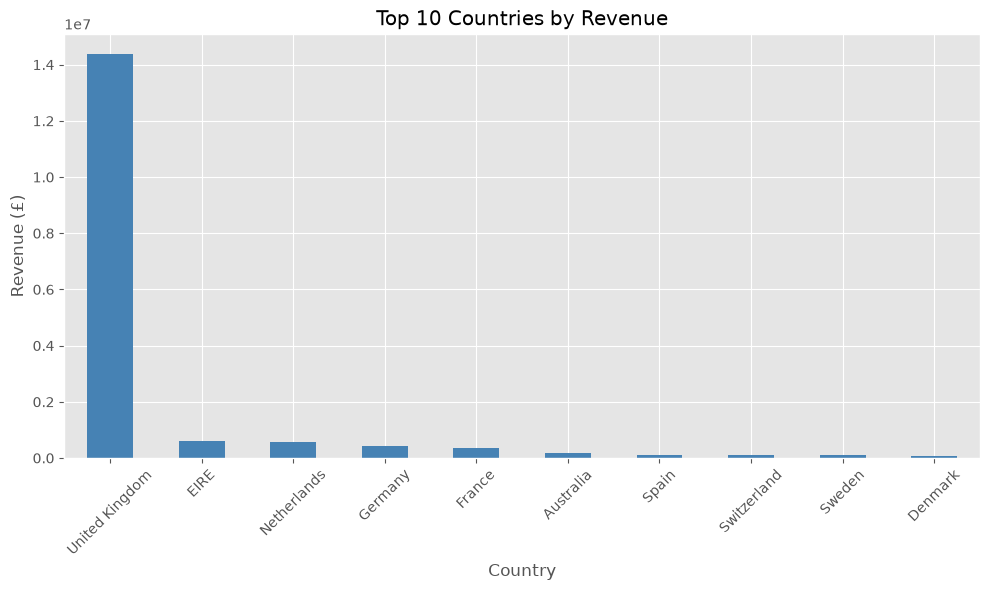

In [8]:
top10 = country_revenue.head(10)

plt.figure(figsize=(10, 6))

top10.plot(kind="bar", color="steelblue")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()



plt.show()

The **United Kingdom** generated the highest revenue by a large margin.

### Top 10 Products by Revenue

Analyze the products that generate the highest revenue.

In [9]:
product_revenue=(
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_products=product_revenue.head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: Revenue, dtype: float64

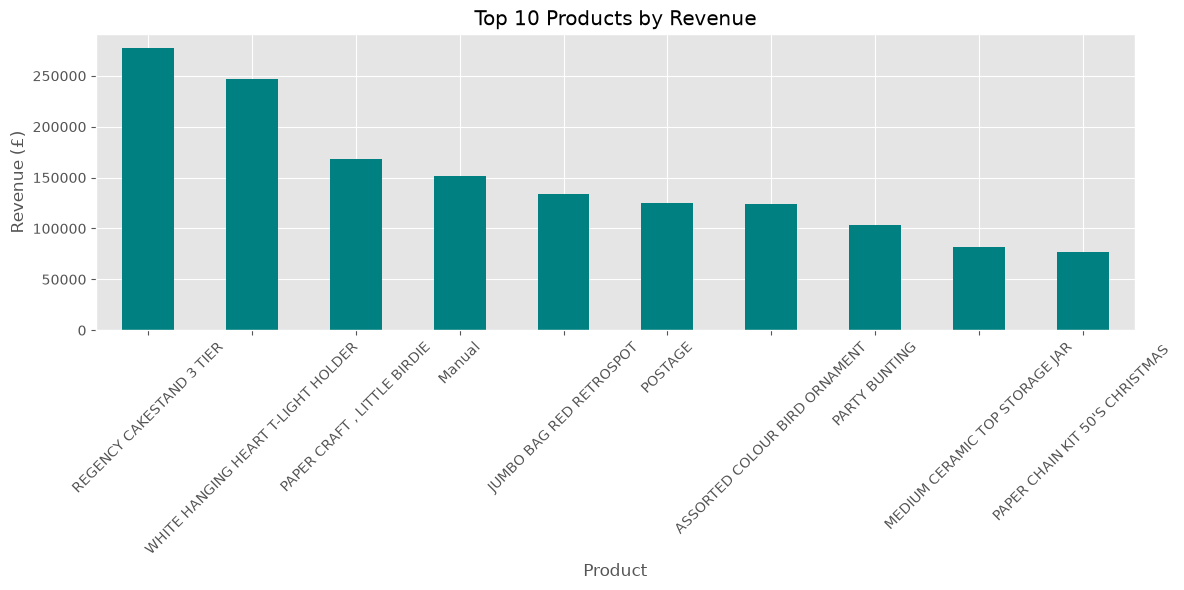

In [10]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar",color="teal")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

- The chart shows the products that generated the highest revenue.
- A few products contribute a large share of the total revenue, while the remaining products generate comparatively lower sales.
- These products can be considered key revenue drivers for the business.

### Monthly Revenue Trend

Analyze how revenue changes over time to identify sales trends and seasonal patterns.

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [12]:
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)

monthly_revenue.head()

InvoiceDate
2009-12    683504.010
2010-01    555802.672
2010-02    504558.956
2010-03    696978.471
2010-04    591982.002
Name: Revenue, dtype: float64

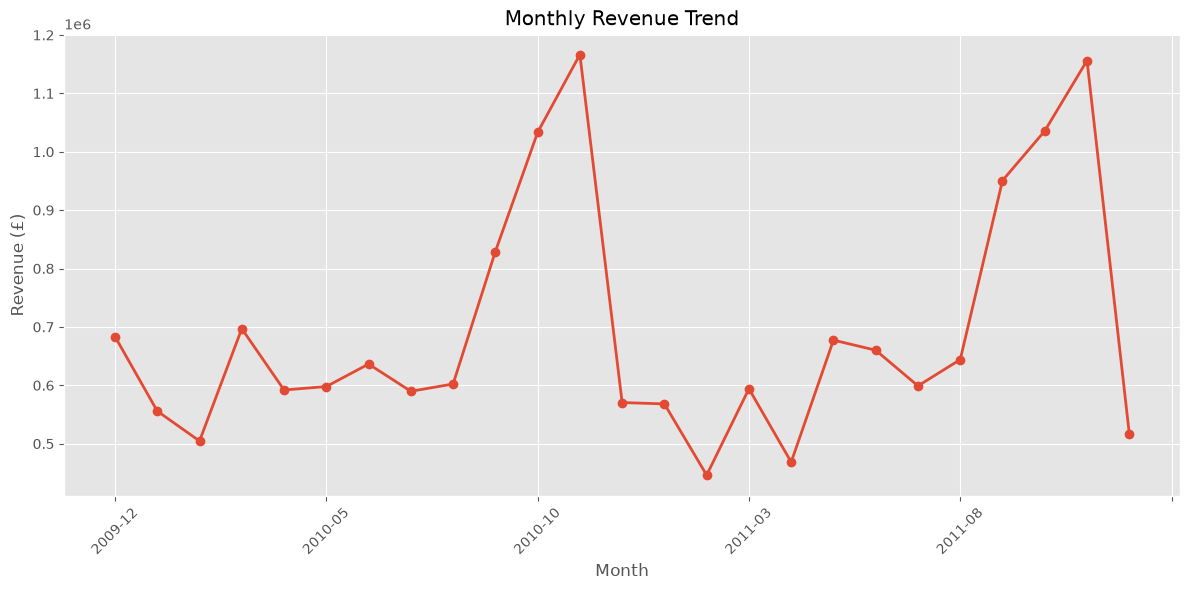

In [13]:
plt.figure(figsize=(12,6))

monthly_revenue.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Observation:**

- Revenue changes from month to month throughout the two-year period.
- Some months show noticeably higher sales, indicating seasonal demand.
- This trend can help the business plan inventory and marketing activities during peak sales periods.

### Top 10 Customers by Revenue

Find the customers who generated the highest revenue during the analysis period.

In [14]:
customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_customers = customer_revenue.head(10)

top_customers

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

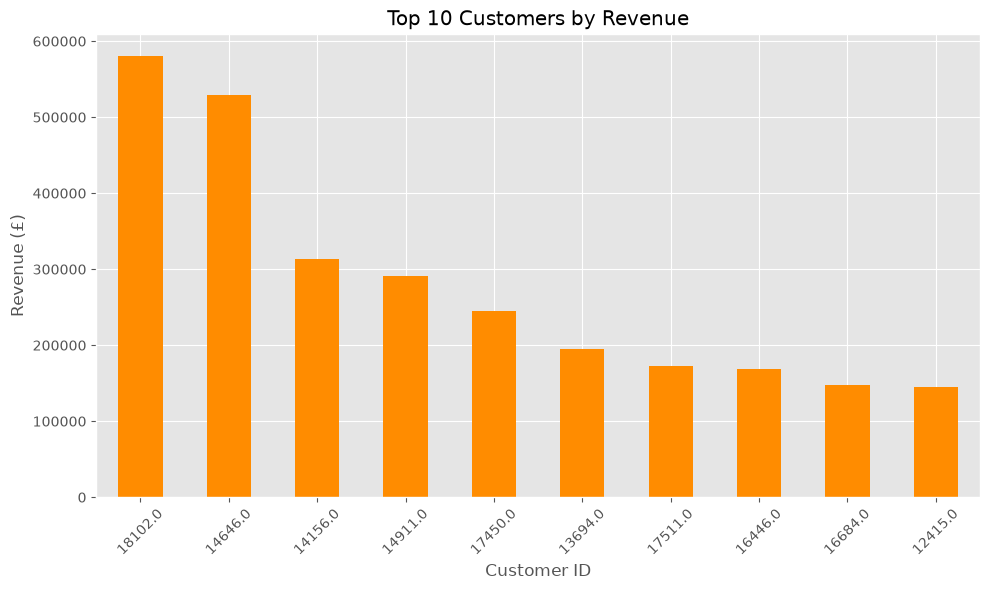

In [15]:
plt.figure(figsize=(10,6))

top_customers.plot(kind="bar", color="darkorange")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation:**

- A small number of customers contributed a significant share of the total revenue.
- These customers can be considered high-value customers.
- Retaining these customers can have a positive impact on future business revenue.

### Monthly Revenue Trend

Analyze the monthly revenue to understand how sales changed over the two-year period.

In [16]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [17]:
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)

monthly_revenue.head()

InvoiceDate
2009-12    683504.010
2010-01    555802.672
2010-02    504558.956
2010-03    696978.471
2010-04    591982.002
Name: Revenue, dtype: float64

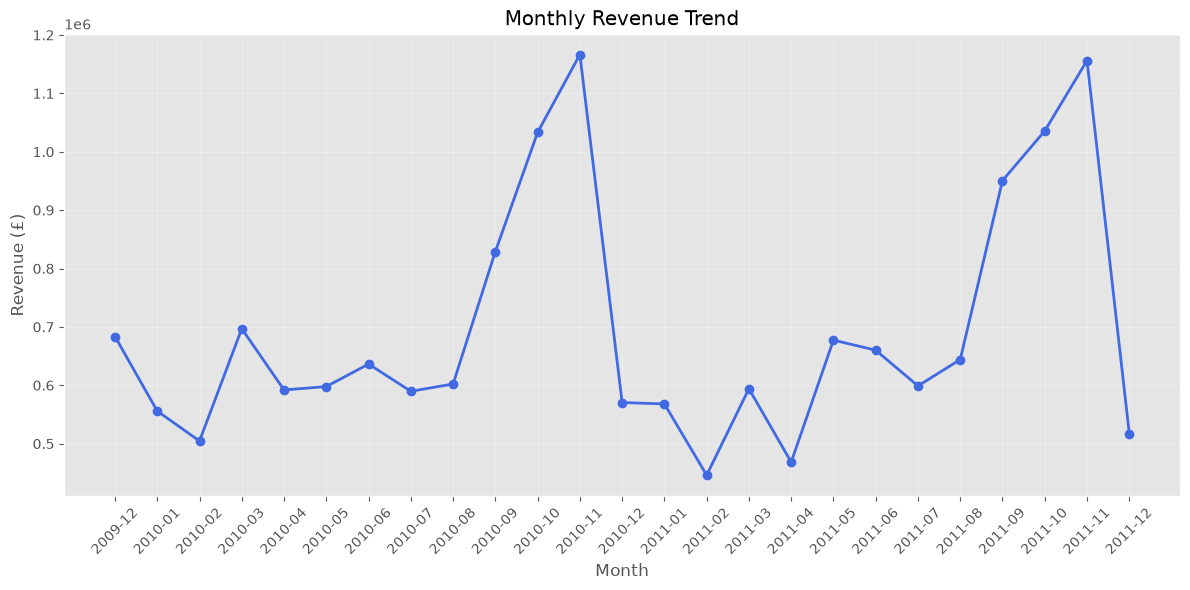

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

**Observation:**

- Revenue varies across different months.
- Some months show higher sales, indicating periods of increased customer demand.
- Understanding these trends can help the business plan inventory and promotional activities more effectively.

### Sales by Month

Analyze sales by month to identify seasonal patterns and peak sales periods.

In [19]:
df["Month"] = df["InvoiceDate"].dt.month_name()

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reindex(month_order)
)

monthly_sales

Month
January      1123903.982
February      950643.876
March        1291060.231
April        1060356.333
May          1275188.530
June         1296417.180
July         1188699.071
August       1246275.640
September    1779704.153
October      2068754.460
November     2322665.632
December     1771135.180
Name: Revenue, dtype: float64

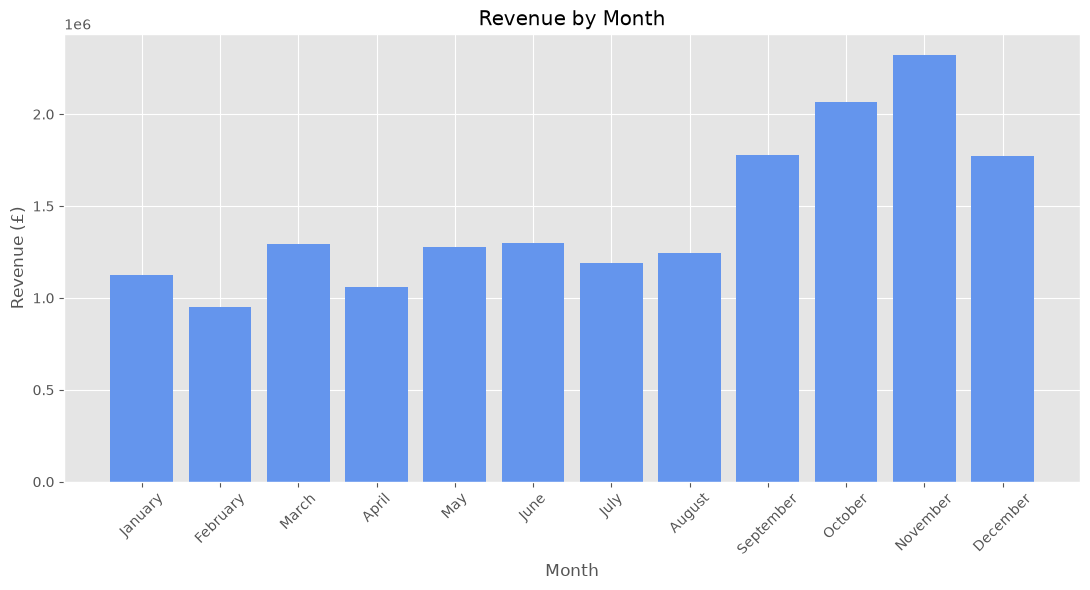

In [20]:
plt.figure(figsize=(11,6))

plt.bar(
    monthly_sales.index,
    monthly_sales.values,
    color="cornflowerblue"
)

plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation:**

- Revenue is not evenly distributed throughout the year.
- Some months consistently record higher sales than others.
- These patterns can help the business prepare inventory and promotional campaigns during busy periods.

### Sales by Hour

Analyze the number of orders placed during different hours of the day.

In [21]:
df["Hour"] = df["InvoiceDate"].dt.hour

hourly_orders = (
    df.groupby("Hour")["Invoice"]
      .count()
)

hourly_orders

Hour
6          1
7       1053
8      15182
9      40980
10     72304
11     96845
12    138988
13    126949
14    106704
15     86142
16     51103
17     26243
18      7178
19      7896
20      1857
Name: Invoice, dtype: int64

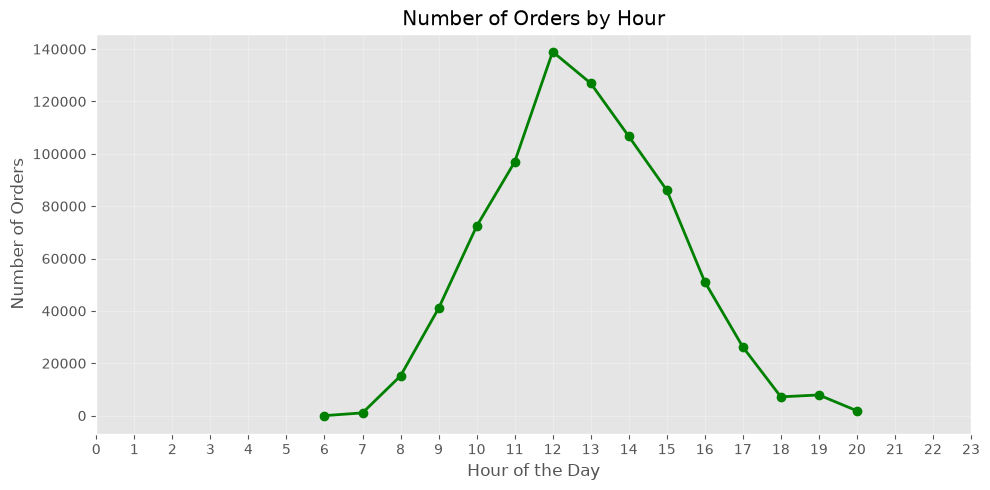

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    hourly_orders.index,
    hourly_orders.values,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Number of Orders by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:**

- Customer activity varies throughout the day.
- Orders are concentrated during specific hours, while early morning and late evening have fewer transactions.
- Understanding peak shopping hours can help schedule promotions and customer support more effectively.

### Sales by Day of the Week

Analyze customer orders across different days of the week to identify the busiest shopping days.

In [23]:
df["Day"] = df["InvoiceDate"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_orders = (
    df.groupby("Day")["Invoice"]
      .count()
      .reindex(day_order)
)

daily_orders

Day
Monday       124947
Tuesday      134021
Wednesday    130777
Thursday     155986
Friday       103157
Saturday        400
Sunday       130137
Name: Invoice, dtype: int64

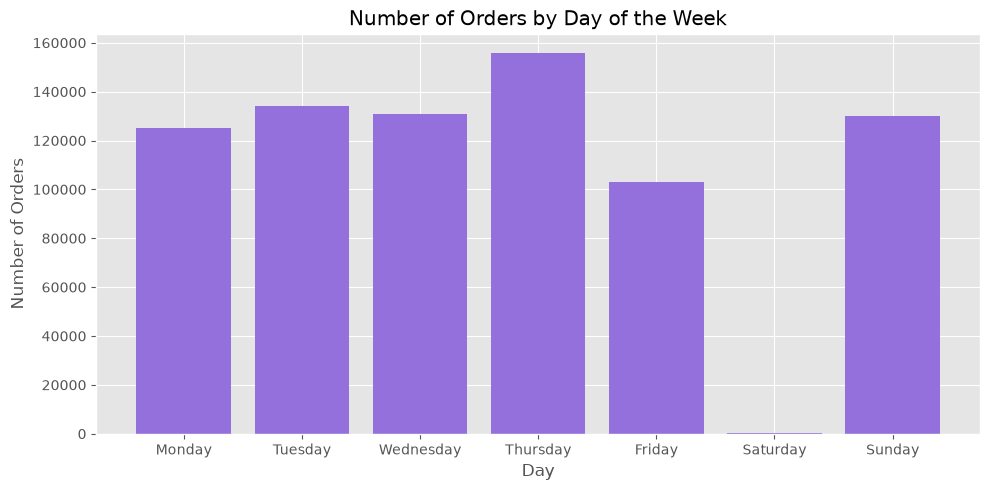

In [24]:
plt.figure(figsize=(10,5))

plt.bar(
    daily_orders.index,
    daily_orders.values,
    color="mediumpurple"
)

plt.title("Number of Orders by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

**Observation:**

- Customer orders vary across different days of the week.
- Some weekdays receive noticeably more orders than others.
- This information can help businesses plan staffing and promotional activities more effectively.

### Revenue Distribution

Analyze how transaction revenue is distributed across the dataset.

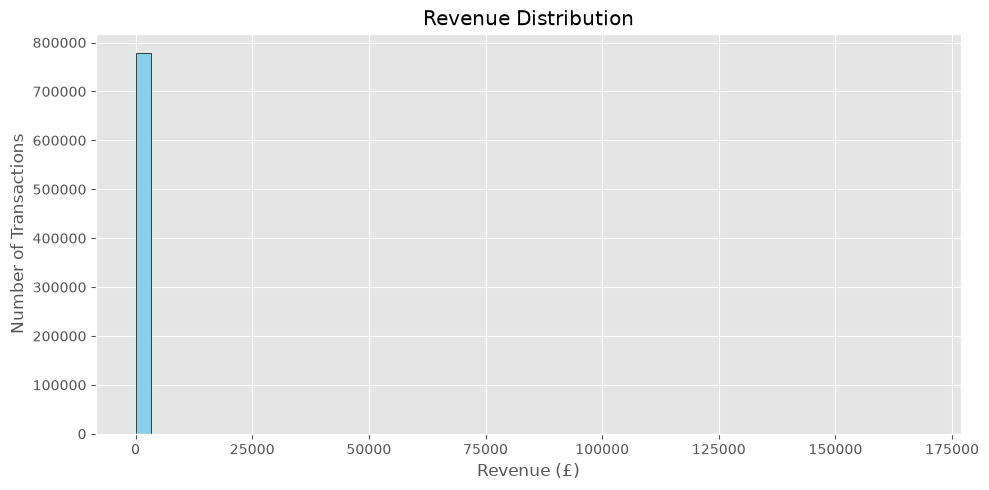

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(df["Revenue"], bins=50, color="skyblue", edgecolor="black")

plt.title("Revenue Distribution")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

**Observation:**

- Most transactions have relatively low revenue.
- A small number of transactions have much higher revenue, creating a right-skewed distribution.
- This indicates that a few large purchases contribute significantly to the overall revenue.

### Quantity Distribution

Analyze the distribution of product quantities purchased in each transaction.

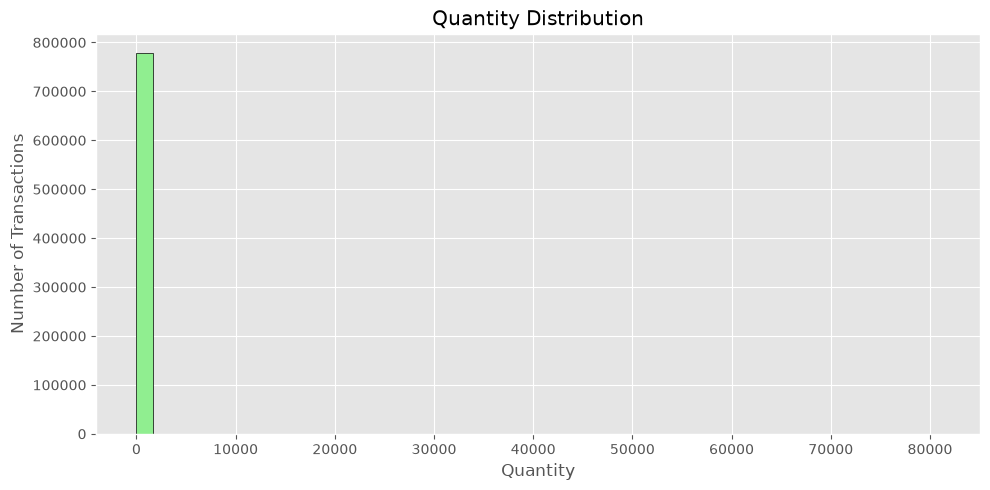

In [26]:
plt.figure(figsize=(10,5))

plt.hist(df["Quantity"], bins=50, color="lightgreen", edgecolor="black")

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

**Observation:**

- Most transactions contain a small number of items.
- Larger quantities occur less frequently.
- The distribution is right-skewed, indicating that bulk purchases are relatively uncommon.

### Correlation Analysis

Measure the relationship between numerical variables using a correlation heatmap.

In [27]:
correlation = df[["Quantity", "Price", "Revenue"]].corr()

correlation

,Quantity,Price,Revenue
Quantity,1.000000,-0.004880,0.827162
Price,-0.004880,1.000000,0.135984
Revenue,0.827162,0.135984,1.000000


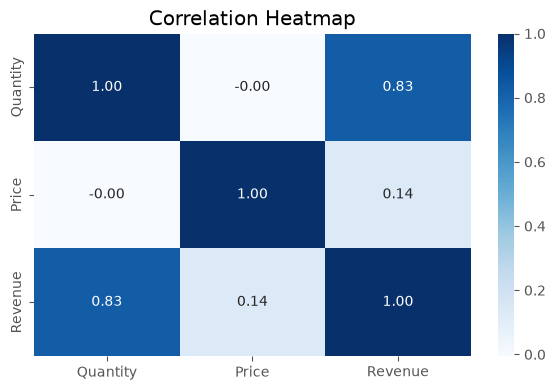

In [28]:
plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

**Observation:**

- Revenue has a strong positive relationship with quantity because purchasing more items generally increases revenue.
- Price also influences revenue, although its relationship may be weaker than quantity.
- The heatmap provides a quick overview of how the numerical variables are related.

### Revenue Outlier Analysis

Use a box plot to identify unusually high or low revenue values.

C:\Users\sarva\AppData\Local\Temp\ipykernel_24116\3875323166.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Revenue"], vert=False)


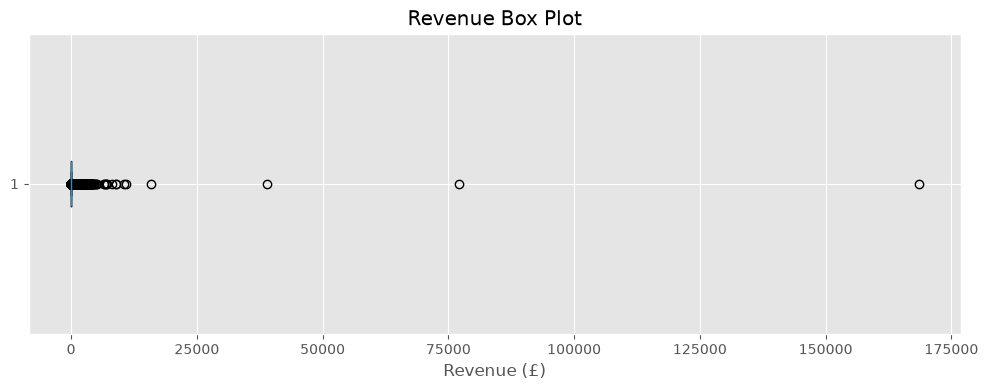

In [29]:
plt.figure(figsize=(10,4))

plt.boxplot(df["Revenue"], vert=False)

plt.title("Revenue Box Plot")
plt.xlabel("Revenue (£)")

plt.tight_layout()
plt.show()

**Observation:**

- The box plot shows several high-value transactions that appear as outliers.
- These values are expected in retail datasets because some customers purchase significantly more than others.
- The outliers represent genuine business transactions rather than data quality issues.